In [1]:
import os
import hashlib
from PIL import Image
from collections import defaultdict
import plotly.graph_objects as go

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor
from torchvision import datasets
from torchvision import transforms
import torch.optim as optim

In [4]:
train_dir = "Fruits/train/train"

In [ ]:

# Annahme, dass alle Bilder jpgs und 100x100 von Höhe und Breite.
alle_100x100 = True
alle_jpg = True

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)       
        with Image.open(img_path) as img:
            # Extension vom Bild speichern.
            extension = os.path.splitext(img_path)[1].lower()
            if img.size != (100, 100):
                print(f"Bild nicht 100x100: {img_path}, Größe: {img.size}")
                alle_100x100 = False
            if extension != ".jpg":
                print("Bild nicht jpg, sondern "+extension)
                alle_jpg = False
            

if alle_100x100:
    print("Alle Bilder sind 100x100!")

if alle_jpg:
    print("Alle Bilder sind JPG.")


KeyboardInterrupt: 

In [3]:
def img_hash(path):
    "Hash eines Bildes aus der Datei"
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()  # MD5 Hash

hashes = {}
duplicates = []

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for file in os.listdir(folder_path):       
        ## Verzerrt?
        img_path = os.path.join(folder_path, file)
        try:
            with Image.open(img_path) as img:
                # RGB Modus?
                if img.mode not in ["RGB", "L"]:
                    print("Ungewöhnlicher Modus:", img_path, "| Modus:", img.mode)
                # Verzerrtes Bild?
                if img.size[0] == 0 or img.size[1] == 0:
                    print("Verzerrtes Bild (0 Größe):", img_path)
        except Exception as e:
            print("Kaputtes / verzerrtes Bild:", img_path, "| Fehler:", e)
            continue

        ## Duplikate?
        path = os.path.join(folder_path, file)
        h = img_hash(path)
        if h in hashes:
            duplicates.append((path, hashes[h]))  # (aktuelles Bild, erstes gefundenes Duplikat)
        else:
            hashes[h] = path

print(f"Gefundene Duplikate: {len(duplicates)}")
for dup, original in duplicates:
    print(f"Duplikat: {dup} | Original: {original}")

Gefundene Duplikate: 0


In [4]:
folders = [
    f for f in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, f))
]

print("Anzahl Labels", len(folders))
print("\n")
# Iterierung durch die neue Variable folders.
anzahl_bilder = 0
for folder in sorted(folders):
    # "folder_path" ist jeweils der Pfad zum Ordner.
    folder_path = os.path.join(train_dir, folder)
    # Bilder werden in Variable "bild" gespeichert und mit der Funktion len wird die Anzahl Bilder herausgefunden.
    bild = len([
        image for image in os.listdir(folder_path)
    ])  
    # Die Bildanzahl wird der Variable "anzahl_bilder" aufaddiert, um später die Gesamtsumme aller Bilder auszugeben.
    anzahl_bilder += bild
    print(f"{folder}: {bild} Bilder")

print("\n")
print("Gesamtanzahl Bilder im Train-Set:", anzahl_bilder,"Bilder.")

Anzahl Labels 33


Apple Braeburn: 492 Bilder
Apple Granny Smith: 492 Bilder
Apricot: 492 Bilder
Avocado: 427 Bilder
Banana: 490 Bilder
Blueberry: 462 Bilder
Cactus fruit: 490 Bilder
Cantaloupe: 492 Bilder
Cherry: 492 Bilder
Clementine: 490 Bilder
Corn: 450 Bilder
Cucumber Ripe: 392 Bilder
Grape Blue: 984 Bilder
Kiwi: 466 Bilder
Lemon: 492 Bilder
Limes: 490 Bilder
Mango: 490 Bilder
Onion White: 438 Bilder
Orange: 479 Bilder
Papaya: 492 Bilder
Passion Fruit: 490 Bilder
Peach: 492 Bilder
Pear: 696 Bilder
Pepper Green: 444 Bilder
Pepper Red: 666 Bilder
Pineapple: 490 Bilder
Plum: 447 Bilder
Pomegranate: 492 Bilder
Potato Red: 450 Bilder
Raspberry: 490 Bilder
Strawberry: 492 Bilder
Tomato: 738 Bilder
Watermelon: 475 Bilder


Gesamtanzahl Bilder im Train-Set: 16854 Bilder.


In [5]:
# Alle Label-Ordner
folders = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]

# Anzahl Bilder pro Klasse + Klassennamen speichern
count_to_labels = defaultdict(list)  # {Anzahl Bilder: [Klassenliste]}
bild_counts = []

for folder in sorted(folders):
    folder_path = os.path.join(train_dir, folder)
    count = len([f for f in os.listdir(folder_path)])
    bild_counts.append(count)
    count_to_labels[count].append(folder)

# Für Plotly: X = Bildanzahl, Y = Anzahl Klassen, Hovertext = Klassennamen
x_values = sorted(count_to_labels.keys())
y_values = [len(count_to_labels[x]) for x in x_values]
hover_texts = [", ".join(count_to_labels[x]) for x in x_values]

# Plotly Balkendiagramm
fig = go.Figure(data=[go.Bar(
    x=x_values,
    y=y_values,
    marker_color='skyblue',
    hovertext=hover_texts,  # Klassennamen beim Hover
    hoverinfo='x+text'
)])

# Layout anpassen
fig.update_layout(
    title="Verteilung der Bilder pro Klasse",
    xaxis_title="Anzahl Bilder pro Klasse",
    title_x=.5,
    yaxis_title="Anzahl Klassen",
    bargap=0.2,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color="black"),
    xaxis=dict(range=[0,1000], dtick=100, showline=True,linecolor='black',linewidth=.4),
    yaxis=dict(dtick=1, showline=True,linecolor='black',linewidth=.4)
)

fig.show()



## Übergeben der Daten

In [5]:
# Daten auf 100x100 skalieren und als Tensor speichern
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(100, scale=(0.7, 1.0)),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])


train_dataset = datasets.ImageFolder(
    root="Fruits/train/train",
    transform=train_transform
)

# 80% Training, 20% Validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])


test_dataset = datasets.ImageFolder(
    root="Fruits/test",
    transform=transform
)
####
BATCH_SIZE = 32

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nn.Sequential(
    # 16 unterschiedliche 3x3x3 Filter
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    # ReLU Funktion 0-x
    nn.ReLU(),
    # nimmt 2×2-Blöcke und wählt das Maximum. Shape dann 50*50
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    # In einen langen Vektor
    nn.Flatten(),
    # Dropout 50%
    nn.Dropout(0.5),
    # Filter*Bild_width*Bild*height
    nn.Linear(32*25*25, len(train_dataset.classes))
).to(device)

criterion = nn.CrossEntropyLoss()
#  weight_decay = L2 Regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [12]:
for epoch in range(5):
    print(epoch)
    model.train()
    total, correct = 0, 0
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc*100:.2f}%")


0
Epoch 1: Loss=0.0093, Accuracy=99.80%
1
Epoch 2: Loss=0.0146, Accuracy=99.73%
2
Epoch 3: Loss=0.0004, Accuracy=100.00%
3
Epoch 4: Loss=0.0026, Accuracy=99.93%
4
Epoch 5: Loss=0.0080, Accuracy=99.78%


In [6]:
# Nach Training der Epoche:
model.eval()  # Dropout/BatchNorm auf Eval
val_correct, val_total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, 1)
        val_correct += (preds == labels).sum().item()
        val_total += labels.size(0)

val_acc = val_correct / val_total
print(f"Validation Accuracy: {val_acc*100:.2f}%")


Validation Accuracy: 95.22%


True Label: Tomato, Predicted: Tomato


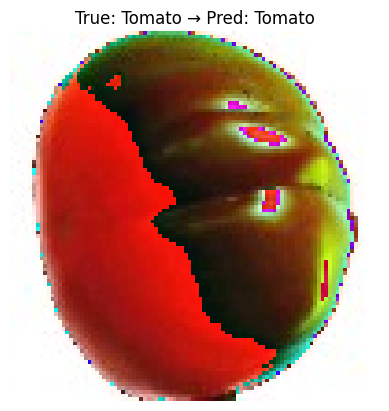

True Label: Apple Braeburn, Predicted: Apple Braeburn


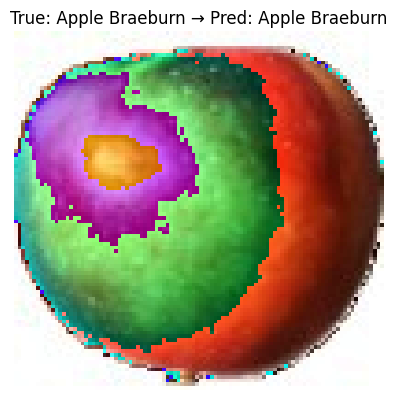

True Label: Passion Fruit, Predicted: Passion Fruit


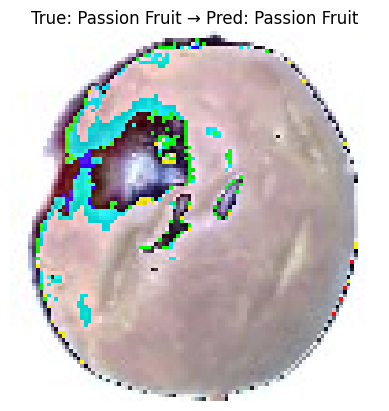

True Label: Pineapple, Predicted: Pineapple


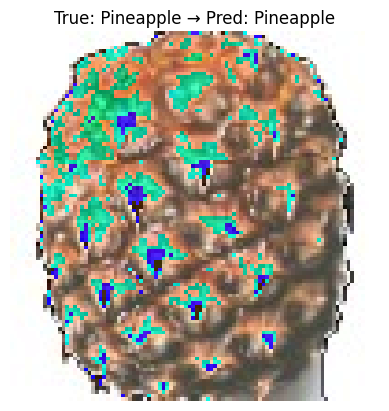

True Label: Peach, Predicted: Peach


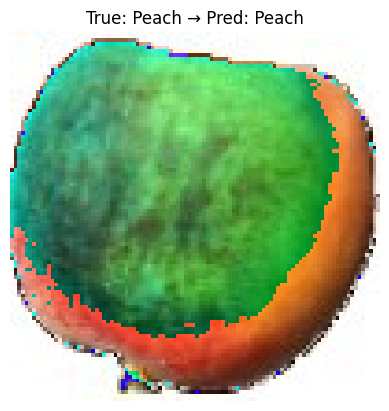

True Label: Orange, Predicted: Orange


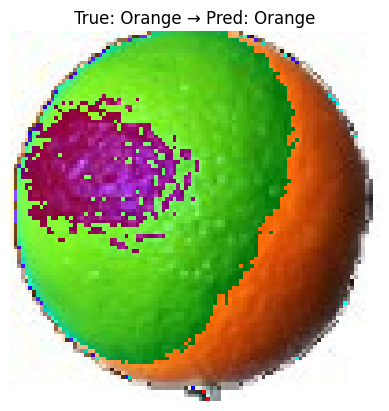

True Label: Kiwi, Predicted: Kiwi


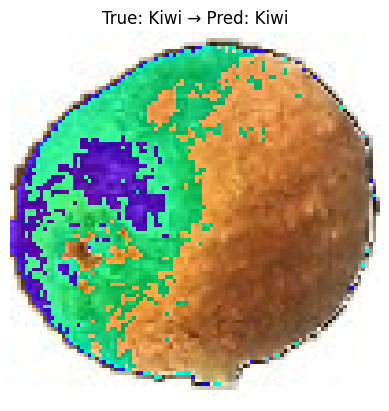

True Label: Apple Granny Smith, Predicted: Apple Granny Smith


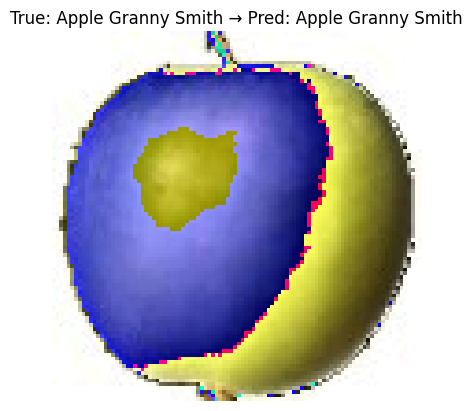

True Label: Pear, Predicted: Pear


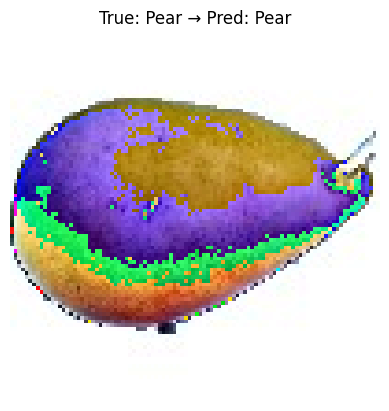

True Label: Pepper Red, Predicted: Pepper Red


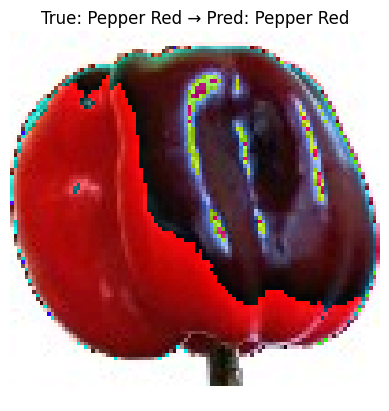

In [10]:
import random
import matplotlib.pyplot as plt

# Gerät festlegen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Validation-Subset Transform (ohne Augmentation!)
val_subset.dataset.transform = transforms.Compose([
    transforms.Resize((100,100)),  # wie im Training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# 10 zufällige Indizes aus dem Validation-Subset auswählen
num_samples = 10
indices = random.sample(range(len(val_subset)), num_samples)

for idx in indices:
    img, true_label = val_subset[idx]  # img ist ein Tensor nach Transform

    # Tensor -> PIL.Image für Anzeige konvertieren
    img_to_show = transforms.ToPILImage()(img)

    # Tensor für Modell vorbereiten (auf Gerät verschieben)
    img_tensor = img.unsqueeze(0).to(device)  # shape [1, 3, 100, 100]

    # Vorhersage
    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = val_subset.dataset.classes[pred_idx]

    # Ausgabe
    print(f"True Label: {val_subset.dataset.classes[true_label]}, Predicted: {pred_label}")

    # Bild anzeigen
    plt.imshow(img_to_show)
    plt.title(f"True: {val_subset.dataset.classes[true_label]} → Pred: {pred_label}")
    plt.axis('off')
    plt.show()



Apple Braeburn.png → Vorhersage: Pear


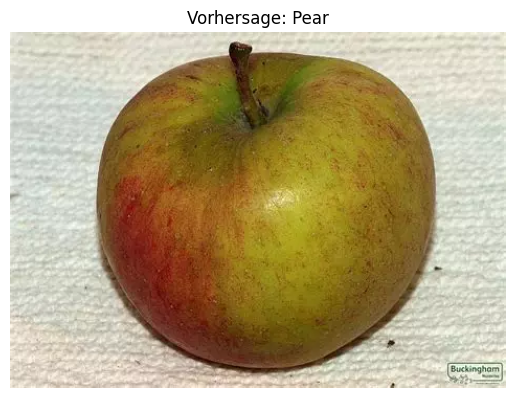

Apple Granny Smith.png → Vorhersage: Pear


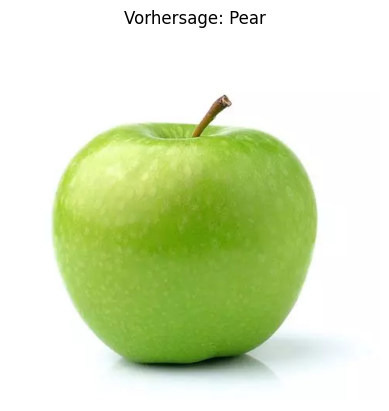

Apricot.png → Vorhersage: Cactus fruit


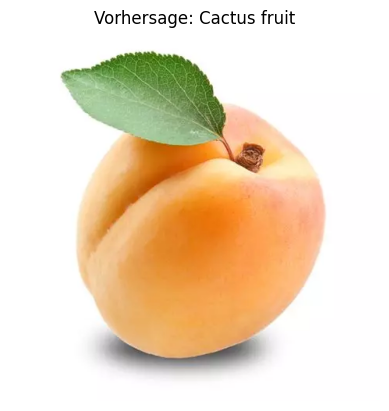

Avocado.png → Vorhersage: Pear


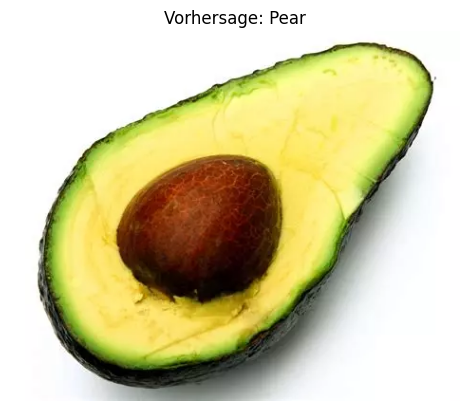

Banana (2).png → Vorhersage: Banana


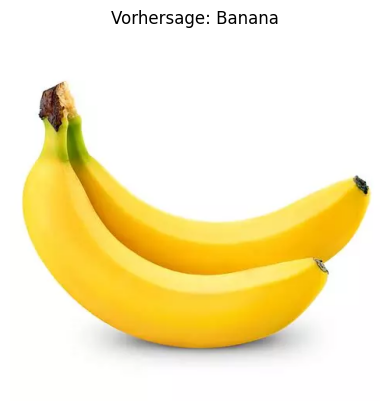

Banana.png → Vorhersage: Banana


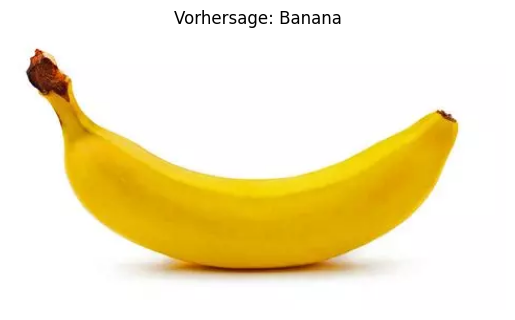

Blueberry.png → Vorhersage: Banana


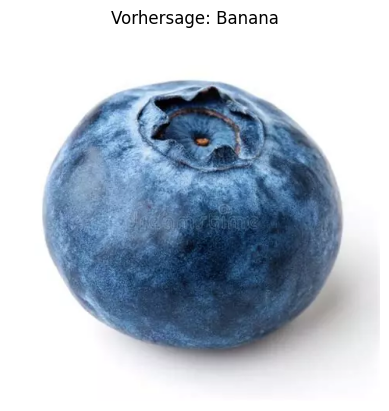

watermelon.jpg → Vorhersage: Cactus fruit


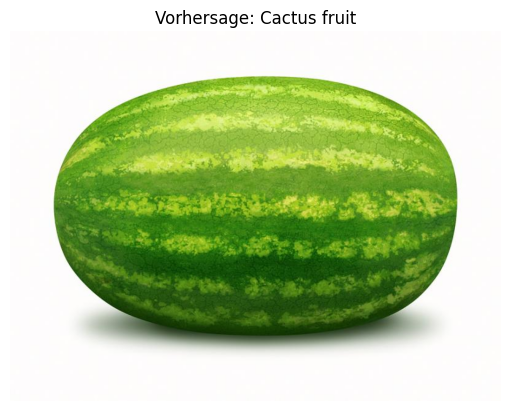

In [11]:

new_dir = "Fruits/new"

transform = transforms.Compose([
    transforms.Resize((100,100)),  # ggf. an Modell anpassen
    transforms.ToTensor()
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

for img_name in sorted(os.listdir(new_dir)):
    img_path = os.path.join(new_dir, img_name)
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # WICHTIG: Tensor auf GPU/CPU

    # Vorhersage
    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = train_dataset.classes[pred_idx]

    # Ausgabe
    print(f"{img_name} → Vorhersage: {pred_label}")

    # Bild anzeigen
    plt.imshow(img)
    plt.title(f"Vorhersage: {pred_label}")
    plt.axis('off')
    plt.show()




In [16]:
import random
import matplotlib.pyplot as plt


# Gerät festlegen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Transformation
transform = transforms.Compose([
    transforms.Resize((100, 100)),  # ggf. auf Modell anpassen
    transforms.ToTensor()
])

# 20 zufällige Indizes aus dem Validierungsset auswählen
num_samples = 20
indices = random.sample(range(len(val_subset)), num_samples)

for idx in indices:
    # Bild und Label laden
    img, true_label = val_subset[idx]  # img ist Tensor oder PIL.Image

    # Wenn img Tensor ist, in PIL konvertieren, damit wir es anzeigen können
    if isinstance(img, torch.Tensor):
        img_to_show = transforms.ToPILImage()(img)
    else:
        img_to_show = img

    # Bild vorbereiten
    img_tensor = transform(img_to_show).unsqueeze(0).to(device)

    # Vorhersage
    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = val_subset.classes[pred_idx]

    # Ausgabe
    print(f"True: {true_label}, Vorhersage: {pred_label}")

    # Bild anzeigen
    plt.imshow(img_to_show)
    plt.title(f"True: {true_label} → Pred: {pred_label}")
    plt.axis('off')
    plt.show()


AttributeError: 'Subset' object has no attribute 'classes'

In [25]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [8]:

model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>